# Advanced pyALF part 2: Postprocessing

Here, we will post-process finished ALF simulations without using `ALF_source` or `Simulation`. This is often more practical with bigger projects, or when the simulation and analysis are performed in different environments.

In [1]:
from py_alf import utils

Find all subdirectories containing `data.h5`.

In [2]:
dirs = utils.find_sim_dirs()
dirs

['./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=2.5',
 './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.0',
 './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.5',
 './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=4.0',
 './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=4.0_xi=0.25_h=3',
 './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0',
 './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_1',
 './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_2',
 './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_3',
 './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_0',
 './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_1',
 './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_2',
 './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_3',

## Custom observables

We define observables that are derived from observables measured during Monte Carlo.

In [3]:
import numpy as np

Correlation ratio 
$1 - \frac{O(\mathbf{k}+\mathbf{\delta})}{\mathbf{k}}$. RG-invariant quantity

In [4]:
def R_k(obs, back, sign, N_orb, N_tau, dtau, latt,
        ks=[(0., 0.)], mat=None, NNs=[(1, 0), (0, 1), (-1, 0), (0, -1)]):
    """RG-invariant quantity derived from a correlatian function.
    
    obs.shape = (N_orb, N_orb, N_tau, latt.N)
    back.shape = (N_orb,)
    """
    if mat is None:
        mat = np.identity(N_orb)
    out = 0
    for k in ks:
        n = latt.k_to_n(k)

        J1 = (obs[..., n].sum(axis=-1) * mat).sum()
        J2 = 0
        for NN in NNs:
            i = latt.nnlistk[n, NN[0], NN[1]]
            J2 += (obs[..., i].sum(axis=-1) * mat).sum() / len(NNs)
        out += (1 - J2/J1)

    return out / len(ks)

Binder cumulant $\left(3 - \frac{\langle s^4 \rangle}{\langle s^2 \rangle^2}\right)/2$. RG-invariant quantity

In [5]:
def binder(obs, sign, N_obs):
    return (3 - obs[2] / obs[1]**2)/2 / sign

Susceptibility $\int_{0}^{\beta}\!\text{d}\tau\, C\left(\mathbf{k},\tau\right)$

In [6]:
def susceptibility(obs, back, sign, N_orb, N_tau, dtau, latt,
                   ks=[[0., 0.]]):
    """Susceptibility of a time-displaced correlatian function.
    
    obs.shape = (N_orb, N_orb, N_tau, latt.N)
    back.shape = (N_orb,)
    """
    out = 0
    for k in ks:
        n = latt.k_to_n(k)
        out += dtau*obs[..., n].trace().sum() / sign
    return out / len(ks)

Extract fermionic single-particle gap from 
$$
\hat{c}^\dag_{\mathbf{k},0} \hat{c}^\dag_{\mathbf{k},\tau} \sim {\rm exp}(-\Delta_{\mathbf{k}} \tau)
$$

In [7]:
from scipy.optimize import curve_fit

def fit_gap_lazy(obs, back, sign, N_orb, N_tau, dtau, latt):
    """Lazily fit Green function to determin gap.
    
    obs.shape = (N_orb, N_orb, N_tau, latt.N)
    """
    i1 = (2*N_tau)//24
    i2 = (4*N_tau)//24
    green = obs[0, 0, i1:i2, :]/sign
    
    def func(x, a, b):
        return a*np.exp(-b*x)
    taus = np.arange(0., N_tau*dtau, dtau)
    res = np.empty((latt.N,), dtype=np.cdouble)
    for n in range(latt.N):
        popt, pcov = curve_fit(func, taus[i1:i2], green[:, n])
        res[n] = popt[1]
    
    return res

In [8]:
custom_obs = {}

In [9]:
custom_obs['R_S']= {
    'needs': ['IsingZ_eq'],
    'function': R_k,
    'kwargs': {}
}

custom_obs['R_chi']= {
    'needs': ['IsingZT_tau'],
    'function': R_k,
    'kwargs': {}
}

custom_obs['B']= {
    'needs': ['m_scal'],
    'function': binder,
    'kwargs': {}
}

# Susceptibility
custom_obs['chi']= {
    'needs': ['IsingZT_tau'],
    'function': susceptibility,
    'kwargs': {}
}

custom_obs['gap_lazy']= {
    'needs': ['Green_tau'],
    'function': fit_gap_lazy,
    'kwargs': {}
}

## Check warmup and autocorrelation

In [10]:
# Enable Jupyter Widget support for matplotlib
%matplotlib widget

In [11]:
from py_alf import check_warmup, check_rebin

In [12]:
check_warmup(dirs, ['m_scal', 'ising_x_scal', 'R_S', 'R_chi', 'B', 'chi'], custom_obs=custom_obs, gui='tk')

m_scal
ising_x_scal
custom R_S
custom R_chi
custom B
custom chi
0.651141721859871 2.0440371705763944e-07
0.6368416496838774 -1.4191531449003164e-06
0.957774389618575 2.1333444761358906e-08
0.998879954423979 7.615627561397304e-08
0.9192144432624727 1.5233280214675318e-07
159.01240749103894 4.794710911062142e-06


In [13]:
check_rebin(dirs, ['m_scal', 'ising_x_scal', 'R_S', 'R_chi', 'B', 'chi'], custom_obs=custom_obs, gui='tk')

m_scal
ising_x_scal
custom R_S
1*676=676
2*338=676
3*225=675
4*169=676
5*135=675
6*112=672
7*96=672
8*84=672
9*75=675
10*67=670
11*61=671
12*56=672
13*52=676
14*48=672
15*45=675
16*42=672
17*39=663
18*37=666
19*35=665
20*33=660
21*32=672
22*30=660
23*29=667
24*28=672
25*27=675
26*26=676
27*25=675
28*24=672
29*23=667
30*22=660
31*21=651
32*21=672
33*20=660
34*19=646
35*19=665
36*18=648
37*18=666
38*17=646
39*17=663
40*16=640
41*16=656
42*16=672
43*15=645
44*15=660
45*15=675
46*14=644
47*14=658
48*14=672
49*13=637
50*13=650
51*13=663
52*13=676
53*12=636
54*12=648
55*12=660
56*12=672
57*11=627
58*11=638
59*11=649
60*11=660
61*11=671
62*10=620
63*10=630
64*10=640
65*10=650
66*10=660
67*10=670
68*9=612
69*9=621
70*9=630
71*9=639
72*9=648
73*9=657
74*9=666
75*9=675
76*8=608
77*8=616
78*8=624
79*8=632
80*8=640
81*8=648
82*8=656
83*8=664
84*8=672
85*7=595
86*7=602
87*7=609
88*7=616
89*7=623
90*7=630
91*7=637
92*7=644
93*7=651
94*7=658
95*7=665
96*7=672
97*6=582
98*6=588
99*6=594
100*6=600
cust

## Symmetrize correlation functions

In [18]:
from math import pi

# Define list of transformations (Lattice, i) -> new_i
# Default analysis will average over all listed elements
def sym_c2_0(latt, i): return i
def sym_c2_1(latt, i): return latt.rotate(i, pi)

symmetry = [sym_c2_0, sym_c2_1]

## Error analysis

In [19]:
from py_alf.analysis import analysis  # The function behind Simulation.analysis

In [22]:
for directory in dirs:
    analysis(directory, custom_obs=custom_obs, symmetry=symmetry, always=True, do_tau=False)

### Analyzing ./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=2.5 ###
/home/jovyan/alf_workshop2020/Presentations/ALF_2024-advanced_pyALF
Custom observables:
custom R_S ['IsingZ_eq']
custom R_chi ['IsingZT_tau']
custom B ['m_scal']
custom chi ['IsingZT_tau']
custom gap_lazy ['Green_tau']


/opt/conda/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:647: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


Scalar observables:
Kin_Pot_E_scal
Part_scal
ising_x_scal
ising_z_scal
m_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
IsingX_eq
IsingZ_eq
### Analyzing ./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.0 ###
/home/jovyan/alf_workshop2020/Presentations/ALF_2024-advanced_pyALF
Custom observables:
custom R_S ['IsingZ_eq']
custom R_chi ['IsingZT_tau']
custom B ['m_scal']
custom chi ['IsingZT_tau']
custom gap_lazy ['Green_tau']
Scalar observables:
Kin_Pot_E_scal
Part_scal
ising_x_scal
ising_z_scal
m_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
IsingX_eq
IsingZ_eq
### Analyzing ./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.5 ###
/home/jovyan/alf_workshop2020/Presentations/ALF_2024-advanced_pyALF
Custom observables:
custom R_S ['IsingZ_eq']
custom R_chi ['IsingZT_tau']
custom B ['m_scal']
custom chi ['IsingZT_tau']
custom gap_lazy ['Green_tau']
Scalar observables:
Kin_Pot_E_scal
Part_scal
ising_x_scal
ising_z_scal
m_sca

/opt/conda/lib/python3.11/site-packages/py_alf/ana.py:604: RuntimeWarning: invalid value encountered in divide
  J = J_obs[:, n] / J_sign


IsingX_eq
IsingZ_eq
### Analyzing ./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_1 ###
/home/jovyan/alf_workshop2020/Presentations/ALF_2024-advanced_pyALF
Custom observables:
custom R_S ['IsingZ_eq']
custom R_chi ['IsingZT_tau']
custom B ['m_scal']
custom chi ['IsingZT_tau']
custom gap_lazy ['Green_tau']
Scalar observables:
Acc_Temp_scal
Kin_Pot_E_scal
Part_scal
ising_x_scal
ising_z_scal
m_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
IsingX_eq
IsingZ_eq
### Analyzing ./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_2 ###
/home/jovyan/alf_workshop2020/Presentations/ALF_2024-advanced_pyALF
Custom observables:
custom R_S ['IsingZ_eq']
custom R_chi ['IsingZT_tau']
custom B ['m_scal']
custom chi ['IsingZT_tau']
custom gap_lazy ['Green_tau']
Scalar observables:
Acc_Temp_scal
Kin_Pot_E_scal
Part_scal
ising_x_scal
ising_z_scal
m_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
IsingX_eq
IsingZ

Load the results into a pandas DataFrame

In [23]:
from py_alf.ana import load_res  # The function behind Simulation.get_obs

In [24]:
res = load_res(dirs)

./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=2.5
No orbital locations saved.
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.0
No orbital locations saved.
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.5
No orbital locations saved.
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=4.0
No orbital locations saved.
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=4.0_xi=0.25_h=3
No orbital locations saved.
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0
No orbital locations saved.
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_1
No orbital locations saved.
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_2
No orbital locations saved.
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_3
No orbital locations saved.
./ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_0
No orbital locations saved.
./ALF

In [25]:
res

,beta,dtau,ham_chem,ham_h,ham_j,ham_t,ham_xi,l1,l2,n_sun,...,IsingZ_eqR,IsingZ_eqR_err,IsingZ_eqR_sum,IsingZ_eqR_sum_err,IsingZ_eq_lattice,lattice,Acc_Temp_scal_sign,Acc_Temp_scal_sign_err,Acc_Temp_scal0,Acc_Temp_scal0_err
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=2.5,16.0,0.1,0.0,2.5,1.0,1.0,0.25,4,4,2,...,"[[[0.6231645862966602, 0.6468295647305491, 0.6...","[[[0.0002064615694461256, 0.000178333495274806...","[0.6231645862966602, 0.6468295647305491, 0.623...","[0.0002064615694461256, 0.0001783334952748064,...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'a1': [1...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'N_coord...",NaN,NaN,NaN,NaN
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.0,16.0,0.1,0.0,3.0,1.0,1.0,0.25,4,4,2,...,"[[[0.438457120763499, 0.48519913459614517, 0.4...","[[[0.00035575133022368636, 0.00029796199600334...","[0.438457120763499, 0.48519913459614517, 0.438...","[0.00035575133022368636, 0.0002979619960033478...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'a1': [1...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'N_coord...",NaN,NaN,NaN,NaN
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.5,16.0,0.1,0.0,3.5,1.0,1.0,0.25,4,4,2,...,"[[[0.25379208642324746, 0.32645404370301767, 0...","[[[0.00033137993278884684, 0.00027389667125880...","[0.25379208642324746, 0.32645404370301767, 0.2...","[0.00033137993278884684, 0.0002738966712588047...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'a1': [1...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'N_coord...",NaN,NaN,NaN,NaN
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=4.0,16.0,0.1,0.0,4.0,1.0,1.0,0.25,4,4,2,...,"[[[0.1347421143587207, 0.22298633100867668, 0....","[[[0.00024050146714491832, 0.00020175097856916...","[0.1347421143587207, 0.22298633100867668, 0.13...","[0.00024050146714491832, 0.0002017509785691635...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'a1': [1...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'N_coord...",NaN,NaN,NaN,NaN
./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=4.0_xi=0.25_h=3,4.0,0.1,0.0,3.0,1.0,1.0,0.25,4,4,2,...,"[[[0.38301275712025323, 0.43949515427215197, 0...","[[[0.006939055897742469, 0.005526421799418885,...","[0.38301275712025323, 0.43949515427215197, 0.3...","[0.006939055897742469, 0.005526421799418885, 0...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'a1': [1...","{'L1': [4.0, 4.0], 'L2': [4.0, -4.0], 'N_coord...",NaN,NaN,NaN,NaN
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0,40.0,0.1,0.0,2.5,1.0,1.0,0.25,10,10,2,...,"[[[0.540622027534418, 0.5411411138923651, 0.54...","[[[0.009489441598722196, 0.009294455016658803,...","[0.540622027534418, 0.5411411138923651, 0.5416...","[0.009489441598722196, 0.009294455016658803, 0...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'a1'...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'N_c...",NaN,NaN,NaN,NaN
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_1,40.0,0.1,0.0,3.0,1.0,1.0,0.25,10,10,2,...,"[[[0.31149981226533163, 0.31175203379224, 0.31...","[[[0.001830608091322252, 0.001866798243703701,...","[0.31149981226533163, 0.31175203379224, 0.3122...","[0.001830608091322252, 0.001866798243703701, 0...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'a1'...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'N_c...",NaN,NaN,NaN,NaN
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_2,40.0,0.1,0.0,3.5,1.0,1.0,0.25,10,10,2,...,"[[[0.034982086983729684, 0.03675664893617012, ...","[[[0.0012535786610827786, 0.001342743709160149...","[0.034982086983729684, 0.03675664893617012, 0....","[0.0012535786610827786, 0.001342743709160149, ...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'a1'...","{'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'N_c...",NaN,NaN,NaN,NaN
./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_3,40.0,0.1,0.0,4.0,1.0,1.0,0.25,10,10,2,...,"[[[0.0032245704858345835, 0.004163812720445962...","[[[0.00017410351989111052, 0.00025089339899929...","[0.0032245704858345835, 0.004163812720445962

## Plot order parameter

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

Text(0, 0.5, '$S(\\mathbf{k}=0)$')

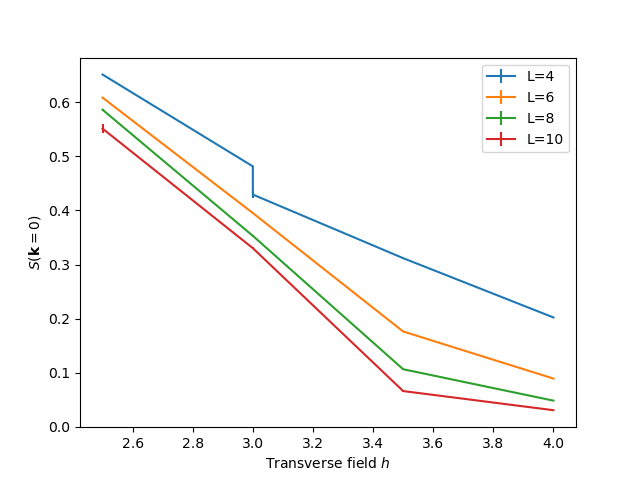

In [33]:
fig, ax = plt.subplots()
for L in [4, 6, 8, 10]:
    df = res[res.l1 == L].sort_values(by='ham_h')
    ax.errorbar(df.ham_h, df.m_scal0, df.m_scal0_err, label=f'L={L}')
ax.legend()
ax.set_xlabel('Transverse field $h$')
ax.set_ylabel('$S(\mathbf{k}=0)$')


## Plot RG-invariant quantities

RG-invariant quantities behave at critical point as:
$$
R = f(L^z/\beta, (h-h_c)L^{1/\nu}, L^{-\omega})
$$
Dismissing dependence on $\beta$ and finite size corrections:
$$
R = f((h-h_c)L^{1/\nu})
$$

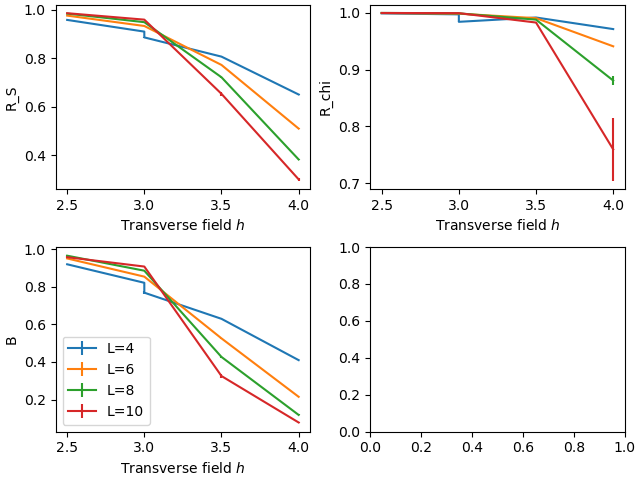

In [34]:
fig, axs = plt.subplots(2, 2, constrained_layout=True)
for L in [4, 6, 8, 10]:
    df = res[res.l1 == L].sort_values(by='ham_h')
    for obs_name, ax in zip(['R_S', 'R_chi', 'B'],
                            axs.flat):
        ax.errorbar(df.ham_h, df[obs_name], df[obs_name+'_err'], label=f'L={L}')
        ax.set_xlabel('Transverse field $h$')
        ax.set_ylabel(obs_name)
ax.legend()

## Attempting data collapse

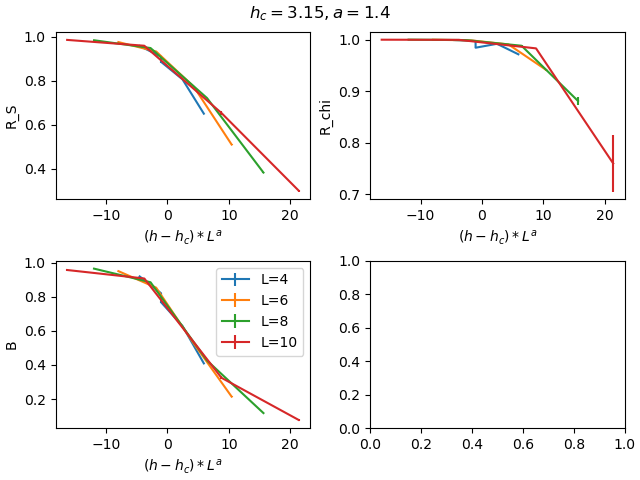

In [37]:
hc = 3.15
a = 1.4
fig, axs = plt.subplots(2, 2, constrained_layout=True)
fig.suptitle(f'$h_c={hc}, a={a}$')
for L in [4, 6, 8, 10]:
    df = res[res.l1 == L].sort_values(by='ham_h')
    for obs_name, ax in zip(['R_S', 'R_chi', 'B'],
                            axs.flat):
        ax.errorbar((df.ham_h-hc)*L**a, df[obs_name], df[obs_name+'_err'], label=f'L={L}')
        ax.set_xlabel('$(h-h_c)*L^a$')
        ax.set_ylabel(obs_name)
ax.legend()

## Plot correlation

### Accessing elemts of the dataframe

In [38]:
for i in res:
    print(i)

beta
dtau
ham_chem
ham_h
ham_j
ham_t
ham_xi
l1
l2
n_sun
R_S
R_S_err
R_chi
R_chi_err
B
B_err
chi
chi_err
gap_lazy
gap_lazy_err
Kin_Pot_E_scal_sign
Kin_Pot_E_scal_sign_err
Kin_Pot_E_scal0
Kin_Pot_E_scal0_err
Kin_Pot_E_scal1
Kin_Pot_E_scal1_err
Kin_Pot_E_scal2
Kin_Pot_E_scal2_err
Part_scal_sign
Part_scal_sign_err
Part_scal0
Part_scal0_err
ising_x_scal_sign
ising_x_scal_sign_err
ising_x_scal0
ising_x_scal0_err
ising_z_scal_sign
ising_z_scal_sign_err
ising_z_scal0
ising_z_scal0_err
m_scal_sign
m_scal_sign_err
m_scal0
m_scal0_err
m_scal1
m_scal1_err
m_scal2
m_scal2_err
Den_eqK
Den_eqK_err
Den_eqK_sum
Den_eqK_sum_err
Den_eqR
Den_eqR_err
Den_eqR_sum
Den_eqR_sum_err
Den_eq_lattice
Green_eqK
Green_eqK_err
Green_eqK_sum
Green_eqK_sum_err
Green_eqR
Green_eqR_err
Green_eqR_sum
Green_eqR_sum_err
Green_eq_lattice
IsingX_eqK
IsingX_eqK_err
IsingX_eqK_sum
IsingX_eqK_sum_err
IsingX_eqR
IsingX_eqR_err
IsingX_eqR_sum
IsingX_eqR_sum_err
IsingX_eq_lattice
IsingZ_eqK
IsingZ_eqK_err
IsingZ_eqK_sum
IsingZ_eqK_

In [39]:
res.index

Index(['./ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=2.5',
       './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.0',
       './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=3.5',
       './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=16.0_xi=0.25_h=4.0',
       './ALF_data/Nematic_Dirac_demo_L1=4_L2=4_beta=4.0_xi=0.25_h=3',
       './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0',
       './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_1',
       './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_2',
       './ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_3',
       './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_0',
       './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_1',
       './ALF_data/temper_Nematic_Dirac_demo_L1=6_L2=6_beta=24.0_xi=0.25_h=2.5/Temp_2',
       '.

In [40]:
item = res.loc['./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0']
item

beta                                                                   40.0
dtau                                                                    0.1
ham_chem                                                                0.0
ham_h                                                                   2.5
ham_j                                                                   1.0
                                                ...                        
lattice                   {'L1': [10.0, 10.0], 'L2': [10.0, -10.0], 'N_c...
Acc_Temp_scal_sign                                                      NaN
Acc_Temp_scal_sign_err                                                  NaN
Acc_Temp_scal0                                                          NaN
Acc_Temp_scal0_err                                                      NaN
Name: ./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_0, Length: 89, dtype: object

In [41]:
item['IsingZ_eqK'].shape

(1, 1, 100)

In [42]:
item['IsingZ_eqK']

array([[[ 0.33900159,  0.36189401,  0.39379484,  0.42712687,
          0.44238679,  0.42645799,  0.39449511,  0.36111071,
          0.33915863,  0.33302062,  0.36051438,  0.38731925,
          0.42675519,  0.47103502,  0.49073971,  0.47039497,
          0.42776438,  0.38742648,  0.36055186,  0.35241598,
          0.39334641,  0.42670737,  0.48404813,  0.55068062,
          0.59007835,  0.55261465,  0.48257617,  0.42597529,
          0.39253216,  0.38110827,  0.42411024,  0.46804993,
          0.55134364,  0.67718245,  0.81479927,  0.6774001 ,
          0.54943688,  0.46666142,  0.42337952,  0.40995153,
          0.43852251,  0.48753994,  0.58405344,  0.78624607,
         55.08135114,  0.78624607,  0.58405344,  0.48753994,
          0.43852251,  0.42262836,  0.42337952,  0.46666142,
          0.54943688,  0.6774001 ,  0.81479927,  0.67718245,
          0.55134364,  0.46804993,  0.42411024,  0.40995153,
          0.39253216,  0.42597529,  0.48257617,  0.55261465,
          0.59007835,  0

### Creating Lattice object

In [43]:
from py_alf import Lattice

In [44]:
latt = Lattice(item['IsingZ_eq_lattice'])

In [45]:
latt.k

array([[-2.51327412,  0.        ],
       [-2.19911486, -0.31415927],
       [-1.88495559, -0.62831853],
       [-1.57079633, -0.9424778 ],
       [-1.25663706, -1.25663706],
       [-0.9424778 , -1.57079633],
       [-0.62831853, -1.88495559],
       [-0.31415927, -2.19911486],
       [ 0.        , -2.51327412],
       [ 0.31415927, -2.82743339],
       [-2.19911486,  0.31415927],
       [-1.88495559,  0.        ],
       [-1.57079633, -0.31415927],
       [-1.25663706, -0.62831853],
       [-0.9424778 , -0.9424778 ],
       [-0.62831853, -1.25663706],
       [-0.31415927, -1.57079633],
       [ 0.        , -1.88495559],
       [ 0.31415927, -2.19911486],
       [ 0.62831853, -2.51327412],
       [-1.88495559,  0.62831853],
       [-1.57079633,  0.31415927],
       [-1.25663706,  0.        ],
       [-0.9424778 , -0.31415927],
       [-0.62831853, -0.62831853],
       [-0.31415927, -0.9424778 ],
       [ 0.        , -1.25663706],
       [ 0.31415927, -1.57079633],
       [ 0.62831853,

### Plot Spin-Spin correlation deep in odered phase

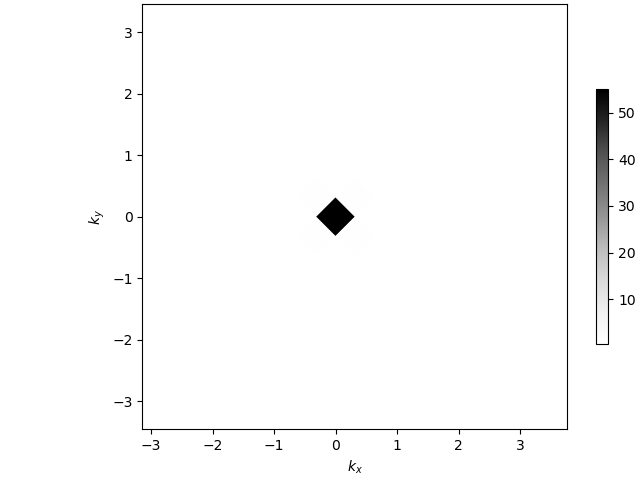

In [46]:
latt.plot_k(item['IsingZ_eqK'][0,0])

### Plot Spin-Spin correlation in disodered phase

In [47]:
item = res.loc['./ALF_data/temper_Nematic_Dirac_demo_L1=10_L2=10_beta=40.0_xi=0.25_h=2.5/Temp_3']

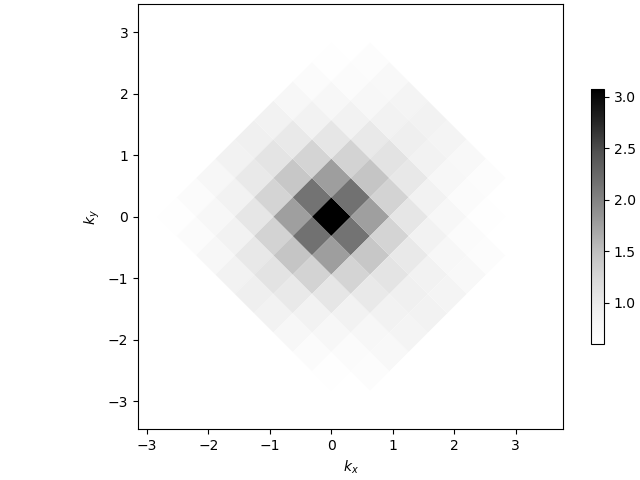

In [48]:
latt.plot_k(item['IsingZ_eqK'][0,0])

### Try to observe the nematic Dirac dispersion

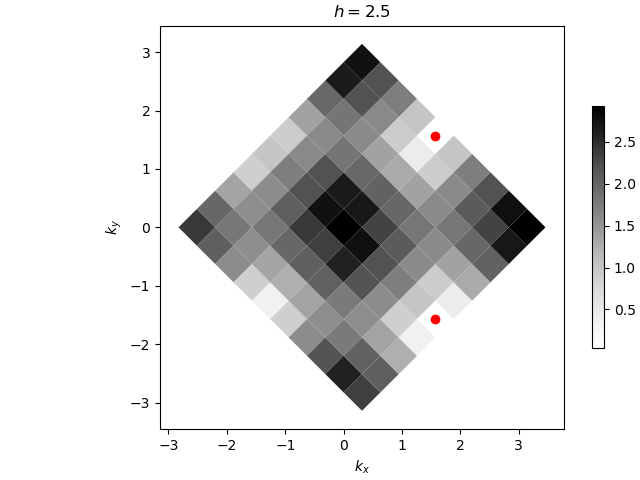

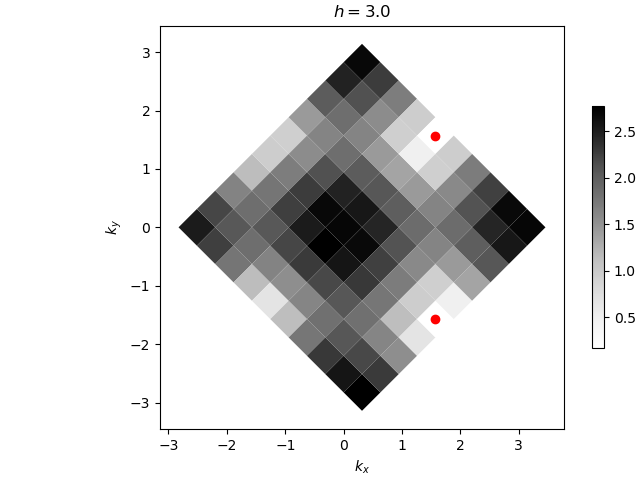

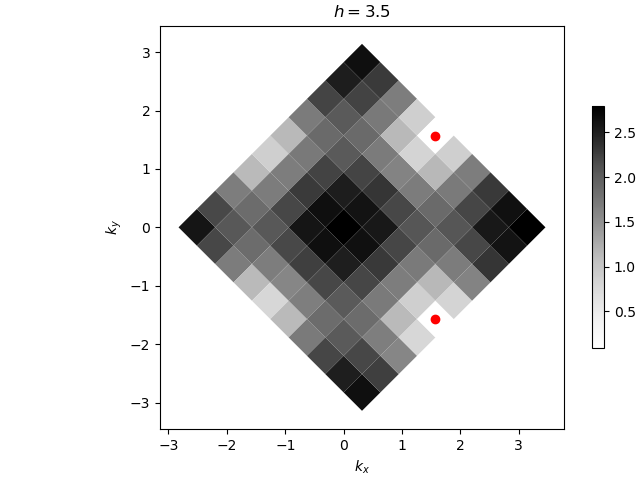

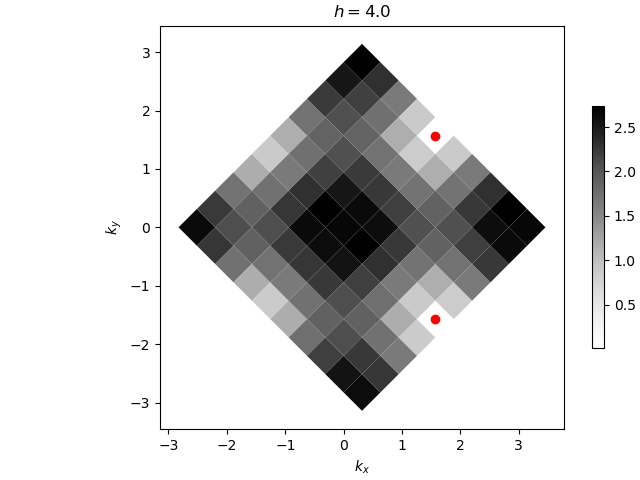

In [50]:
df = res[res.l1 == 10]
latt = Lattice([10, 10], [10, -10], [1, 1], [1, -1])
for i in df.index:
    latt.plot_k(res.loc[i, 'gap_lazy'])
    plt.title(f'$h = {res.loc[i, "ham_h"]}$')
    p = np.pi/2
    plt.plot([p, p], [p, -p], 'o', color='red')